In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize the data (scale pixels to [0,1])
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. One-hot encode the labels (e.g., 3 -> [0,0,0,1,0,0,0,0,0,0])
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 4. Build the ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)),       
    Dense(128, activation='relu'),       
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),        
    Dense(10, activation='softmax')    
])

# 5. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 6. Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# 7. Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/5


2025-07-02 21:53:21.632889: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8157 - loss: 0.6093 - val_accuracy: 0.9647 - val_loss: 0.1204
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9629 - loss: 0.1237 - val_accuracy: 0.9625 - val_loss: 0.1241
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9735 - loss: 0.0857 - val_accuracy: 0.9712 - val_loss: 0.0990
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9806 - loss: 0.0628 - val_accuracy: 0.9757 - val_loss: 0.0816
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9847 - loss: 0.0505 - val_accuracy: 0.9750 - val_loss: 0.0913
  8/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9908 - loss: 0.0309  

2025-07-02 21:54:15.515351: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9687 - loss: 0.1119
Test accuracy: 0.9727


In [8]:
model.save('mnist_ann.h5')

In [9]:
#Testing >>>
import numpy as np

# Reshape the image to (1, 28, 28)
single_image = x_test[20].reshape(1, 28, 28)

# Make prediction
prediction = model.predict(single_image)
prediction

# Show the result
predicted_class = np.argmax(prediction)
print(f"Predicted digit: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Predicted digit: 9


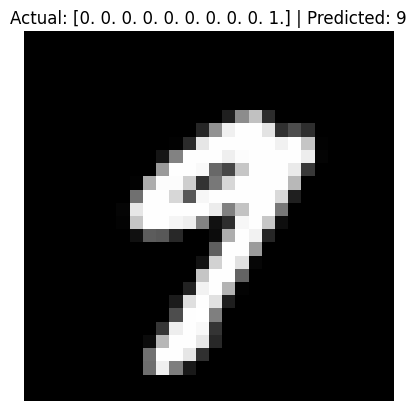

In [10]:
import matplotlib.pyplot as plt

plt.imshow(x_test[20], cmap='gray')
plt.title(f"Actual: {y_test[20]} | Predicted: {predicted_class}")
plt.axis('off')
plt.show()
